In [1]:
import numpy as np
import os
import matplotlib.pyplot as plt
import scipy as sp
import scipy.ndimage
import json
import skimage.io

toppath = '/mpc/homes/fische_r/nanotom_data/2023_COELY_postmortem'
processing_dict_path = os.path.join(toppath, 'processing_data.json')

In [2]:
series = 'C'
sample = '4'

In [3]:
sample_path = os.path.join(toppath, series+'_series', series+'_'+sample)
stage = 'preop'

In [4]:
outputpath = os.path.join(sample_path, series+'_'+sample+'_'+stage+'_rotcrop.tif')

In [5]:
im = skimage.io.imread(outputpath)

In [6]:
sample_path = os.path.join(toppath, series+'_series', series+'_'+sample)
stage = 'postop_2'

In [7]:
outputpath = os.path.join(sample_path, series+'_'+sample+'_'+stage+'_rotcrop.tif')

In [8]:
im2 = skimage.io.imread(outputpath)

In [9]:
vmin = -0.0587
vmax = 0.3144

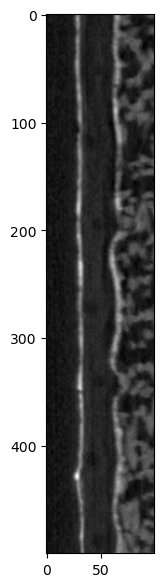

In [10]:
plt.figure(figsize=(12,7))
plt.imshow(im[300:800,250,:], 'gray')

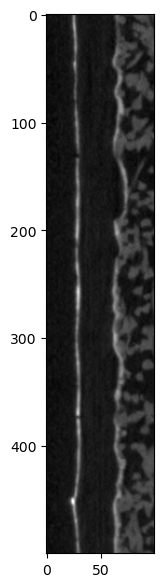

In [11]:
plt.figure(figsize=(12,7))
plt.imshow(im2[300:800,250,:], 'gray')

In [49]:
test = im[300:800,250,:].copy()

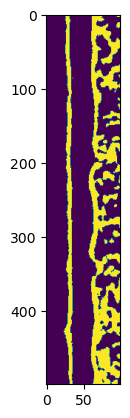

In [50]:
plt.imshow(test>0.3)

In [51]:
line = np.argmax(test>0.3, axis=1)

In [52]:
for i in range(len(line)):
    test[...,:line[i]+10] = 0

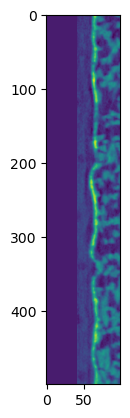

In [53]:
plt.imshow(test)

In [61]:
area = np.argmax(im>0.3, axis=2)

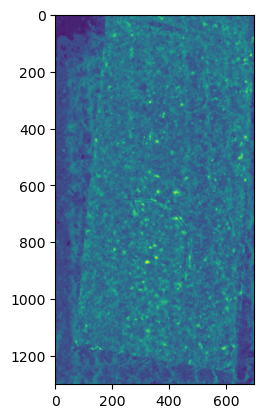

In [69]:
plt.imshow(im.max(axis=2))

In [65]:
area.mean()

31.91831208791209

In [66]:
line.mean()

28.726

In [67]:
np.median(area)

28.0

In [73]:
def crop_cathode_CL(im):
    area = np.argmax(im>0.3, axis=2)
    med = np.median(area).astype(int)
    for x in range(im.shape[0]):
        for y in range(im.shape[1]):
            crop = area[x,y]
            if np.abs(crop-med)>10:
                crop = med
            crop = crop+10
            im[x,y,:crop] = 0

    return im

In [74]:
cropped = crop_cathode_CL(im)

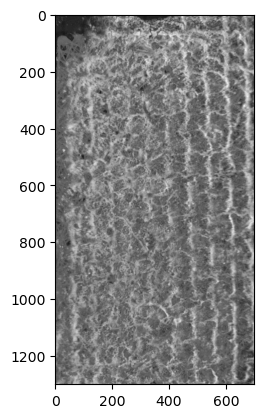

In [77]:
plt.imshow(cropped.max(axis=2), 'gray')

## Use CL as deliminators and cut a "isosurface" at the center through the membrane
find peaks, use neighbor position if not found 

In [11]:
import os
import skimage.io
import matplotlib.pyplot as plt

In [13]:
import scipy as sp
import scipy.signal

In [25]:
import numpy as np

In [96]:
import scipy.ndimage

In [125]:
im = skimage.io.imread('/mnt/nas_nanotomData/CT_Data_PSI/FR54/2023_COELY_postmortem/A_series/A_11/A_11_postop_1_rotcrop.tif')

In [126]:
im = im[100:1100,50:550,:]

In [9]:
a = 500
b = 300

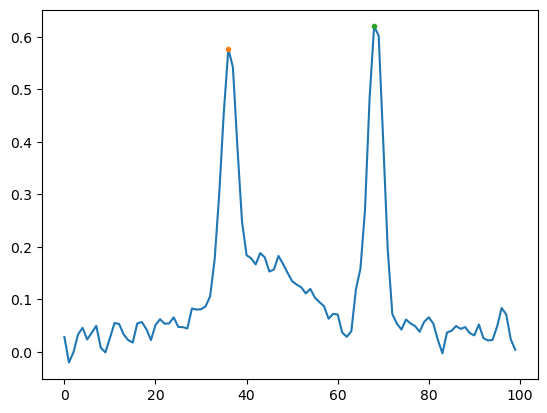

In [22]:
plt.plot(im[a,b,:])
for (x,y) in zip(peaks, props['peak_heights']):
    plt.plot(x,y,'.')

In [14]:
test = im[a,b,:].copy()

In [19]:
peaks, props = sp.signal.find_peaks(test, height=0.3, distance=10)

In [20]:
peaks

array([36, 68])

In [21]:
props

{'peak_heights': array([0.57733309, 0.6197108 ])}

In [131]:
def search_crude_CL(im):
    med = np.median(im)
    shp = im.shape
    CL = np.zeros((shp[0],shp[1],2), dtype = int)
    for x in range(shp[0]):
        for y in range(shp[1]):
            peaks, props = sp.signal.find_peaks(im[x,y,:], height=6.25*med, distance=12, prominence=4.5*med)
            LP = len(peaks)
            if LP>0 and LP<3:
                CL[x,y,-LP:] = peaks
    return CL    #, excess_peaks

In [122]:
def find_center_surface(CL):
    CL0 = sp.ndimage.median_filter(CL[:,:,0], size = 10)
    CL1 = sp.ndimage.median_filter(CL[:,:,1], size = 10)

    IFcoords = np.uint16((CL0+CL1)/2)

    return IFcoords

def extract_center_face(im, IFcoords, filtersize=1):
    fs = filtersize
    shp = IFcoords.shape
    interface = np.zeros(shp)
    for x in range(shp[0]):
        for y in range(shp[1]):
            z = IFcoords[x,y]
            interface[x,y] = im[x,y,z]
            # interface[x,y] = im[x-fs:x+fs,y-fs:y+fs,z-fs:z+fs].mean()  #small mean filtering

    return interface

def cut_through_membrane_center(im):
    CL = search_crude_CL(im)
    IFcoords = find_center_surface(CL)
    interface = extract_center_face(im, IFcoords)
    return interface

In [132]:
interface = cut_through_membrane_center(im)

/tmp/ipykernel_17296/3727834775.py:16: RuntimeWarning: Mean of empty slice.
  interface[x,y] = im[x-fs:x+fs,y-fs:y+fs,z-fs:z+fs].mean()  #small mean filtering


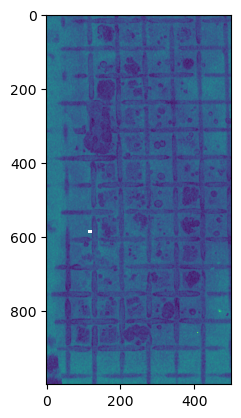

In [133]:
plt.imshow(interface)